# Autoencoder Workflow (4-Class Merge)

This notebook is split into a few practical stages so you do not have to run everything every time:
1. Setup and helper definitions
2. Configuration
3. Data preparation + train/val/test split
4. Model training
5. Loss visualization by epoch (find best epoch)
6. Test evaluation + save outputs

In [1]:
import math
from fnmatch import fnmatch
from pathlib import Path
from typing import Iterable, Tuple

import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
import matplotlib.pyplot as plt

FOUR_CLASS_NAMES = {
    0: "background",
    1: "class_1",
    2: "class_2",
    3: "class_3",
}

WHITE_MATTER_RAW_LABELS = {2, 41}
CORTICAL_CORE_RAW_LABELS = {3, 42}


class ConvAutoencoder(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        input_size: int,
        latent_spatial: int,
        base_channels: int,
        latent_channels: int,
    ) -> None:
        super().__init__()

        if input_size % latent_spatial != 0:
            raise ValueError("input_size must be divisible by latent_spatial")
        factor = input_size // latent_spatial
        if factor & (factor - 1) != 0:
            raise ValueError("input_size / latent_spatial must be a power of 2")
        down_steps = int(math.log2(factor))

        encoder_layers: list[nn.Module] = []
        ch = in_channels
        for i in range(down_steps):
            out_ch = base_channels * (2 ** i)
            encoder_layers.append(nn.Conv2d(ch, out_ch, kernel_size=3, padding=1, padding_mode="replicate"))
            encoder_layers.append(nn.ReLU(inplace=True))
            encoder_layers.append(
                nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=2, padding=1, padding_mode="replicate")
            )
            encoder_layers.append(nn.ReLU(inplace=True))
            ch = out_ch
        encoder_layers.append(nn.Conv2d(ch, latent_channels, kernel_size=3, padding=1, padding_mode="replicate"))
        encoder_layers.append(nn.ReLU(inplace=True))
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers: list[nn.Module] = []
        ch = latent_channels
        for i in reversed(range(down_steps)):
            out_ch = base_channels * (2 ** i)
            decoder_layers.append(nn.Conv2d(ch, ch, kernel_size=3, padding=1, padding_mode="replicate"))
            decoder_layers.append(nn.ReLU(inplace=True))
            decoder_layers.append(nn.Upsample(scale_factor=2, mode="nearest"))
            decoder_layers.append(nn.Conv2d(ch, out_ch, kernel_size=3, padding=1, padding_mode="replicate"))
            decoder_layers.append(nn.ReLU(inplace=True))
            ch = out_ch
        decoder_layers.append(nn.Conv2d(ch, out_channels, kernel_size=1))
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


def _iter_nifti_paths(nifti_dir: str, pattern: str) -> Iterable[Path]:
    root = Path(nifti_dir)
    if not root.exists():
        raise FileNotFoundError(f"Directory not found: {nifti_dir}")
    strict_matches = [path for path in root.rglob(pattern) if path.is_file()]
    if strict_matches:
        for path in strict_matches:
            yield path
        return

    pat = pattern.lower()
    fallback_patterns = {pat}
    if not pat.startswith("*"):
        fallback_patterns.add(f"*{pat}")
    if not pat.endswith("*"):
        fallback_patterns.add(f"{pat}*")
    if not (pat.startswith("*") and pat.endswith("*")):
        fallback_patterns.add(f"*{pat}*")

    for path in root.rglob("*.nii*"):
        if not path.is_file():
            continue
        name = path.name.lower()
        if any(fnmatch(name, p) for p in fallback_patterns):
            yield path


def _load_nifti_slices(
    nifti_path: str,
    axis: int,
    min_nonzero_ratio: float,
    max_slices: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    img = nib.load(nifti_path)
    data = img.get_fdata().astype("float32")
    if data.ndim != 3:
        raise ValueError("Expected a 3D NIfTI volume")

    data = np.moveaxis(data, axis, 0)
    nonzero_ratio = (data > 0).mean(axis=(1, 2))
    keep = np.where(nonzero_ratio >= min_nonzero_ratio)[0]
    if keep.size == 0:
        keep = np.arange(data.shape[0])
    if max_slices > 0 and keep.size > max_slices:
        pick = np.linspace(0, keep.size - 1, max_slices)
        keep = keep[np.round(pick).astype(int)]

    return data[keep], keep, nonzero_ratio


def _merge_labels_to_four_classes(labels_raw: np.ndarray, background_label: int) -> Tuple[np.ndarray, list[int]]:
    labels_idx = np.full(labels_raw.shape, 3, dtype="int64")
    labels_idx[labels_raw == int(background_label)] = 0

    wm_mask = np.isin(labels_raw, list(WHITE_MATTER_RAW_LABELS))
    labels_idx[wm_mask] = 1

    cortical_mask = np.isin(labels_raw, list(CORTICAL_CORE_RAW_LABELS))
    cortical_mask |= (labels_raw >= 1000) & (labels_raw <= 1035)
    cortical_mask |= (labels_raw >= 2000) & (labels_raw <= 2035)
    labels_idx[cortical_mask] = 2

    known_raw = {int(background_label)} | WHITE_MATTER_RAW_LABELS | CORTICAL_CORE_RAW_LABELS
    deep_other_raw = []
    for raw_val in sorted(int(v) for v in np.unique(labels_raw)):
        if raw_val in known_raw:
            continue
        if 1000 <= raw_val <= 1035:
            continue
        if 2000 <= raw_val <= 2035:
            continue
        if raw_val <= 0:
            continue
        deep_other_raw.append(raw_val)

    return labels_idx, deep_other_raw


def _split_indices(n: int, val_split: float, test_split: float, seed: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    if val_split < 0 or test_split < 0:
        raise ValueError("val_split and test_split must be >= 0")
    if val_split + test_split >= 1:
        raise ValueError("val_split + test_split must be < 1")

    gen = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=gen)
    n_test = int(n * test_split)
    n_val = int(n * val_split)
    n_train = n - n_val - n_test
    if n_train <= 0:
        raise ValueError("Split leaves no training samples")

    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    test_idx = perm[n_train + n_val:]
    return train_idx, val_idx, test_idx


def _focal_loss(
    logits: torch.Tensor,
    target: torch.Tensor,
    class_weights: torch.Tensor | None,
    gamma: float = 2.0,
) -> torch.Tensor:
    ce = F.cross_entropy(logits, target, weight=class_weights, reduction="none")
    pt = torch.exp(-ce)
    loss = ((1.0 - pt) ** gamma) * ce
    return loss.mean()


def _run_epoch(
    x: torch.Tensor,
    target: torch.Tensor,
    idx: torch.Tensor,
    model: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    class_weights: torch.Tensor | None,
    batch_size: int,
    device_obj: torch.device,
    train: bool,
) -> float:
    if idx.numel() == 0:
        return 0.0

    model.train() if train else model.eval()
    total_loss = 0.0
    seen = 0

    for start in range(0, idx.numel(), batch_size):
        batch_idx = idx[start:start + batch_size]
        xb = x[batch_idx].to(device_obj)
        yb = target[batch_idx].to(device_obj)

        if train:
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = _focal_loss(logits, yb, class_weights)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                logits, _ = model(xb)
                loss = _focal_loss(logits, yb, class_weights)

        bs = xb.shape[0]
        total_loss += float(loss.item()) * bs
        seen += bs

    return total_loss / max(1, seen)


def _save_preview(
    input_slice: np.ndarray,
    recon_slice: np.ndarray,
    out_path: Path,
    vmin: int,
    vmax: int,
    preview_idx: int,
    mismatch_ratio: float,
    mean_abs_diff: float,
) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(6, 3.6))
    axes[0].imshow(input_slice, cmap="tab20", vmin=vmin, vmax=vmax)
    axes[0].set_title("input")
    axes[0].axis("off")
    axes[1].imshow(recon_slice, cmap="tab20", vmin=vmin, vmax=vmax)
    axes[1].set_title("recon")
    axes[1].axis("off")
    fig.suptitle(f"Slice index: {preview_idx}", fontsize=10)
    fig.text(
        0.5,
        0.01,
        f"Difference: mismatch={mismatch_ratio * 100:.2f}% | mean_abs_diff={mean_abs_diff:.4f}",
        ha="center",
        va="bottom",
    )
    fig.tight_layout(rect=[0, 0.08, 1, 0.93])
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


def _save_pca_plot(z_vec: torch.Tensor, out_path: Path) -> None:
    z = z_vec.detach().cpu().numpy()
    if z.shape[0] < 2:
        print("PCA skipped: need at least 2 samples")
        return

    z = z - z.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(z, full_matrices=False)
    k = min(2, vt.shape[0])
    proj = z @ vt[:k].T
    if k == 1:
        proj = np.concatenate([proj, np.zeros((proj.shape[0], 1))], axis=1)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(4, 4))
    plt.scatter(proj[:, 0], proj[:, 1], s=12)
    plt.title("PCA of latent vectors")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

In [349]:
# Config
NIFTI_DIR = "fwp_brain_volume_clustering_test_data"
PATTERN = "seg.nii*"
NIFTI_PATH = None  # set a direct path to force one volume

TRAIN_SUBJECTS = 1
VAL_SUBJECTS = 1
TEST_SUBJECTS = 15
TEST_SUBJECT_CHUNK_INDEX = 69
TEST_SUBJECT_STRICT_CHUNKS = False  # True: require full chunk size, False: allow smaller final chunk
MAX_SUBJECTS_TO_LOAD = None  # optional cap before splitting

# Fixed normalized slice selection for subject-level latent export
FIXED_SLICE_NORM_POS = 0.5      # 0.0=first informative, 0.5=middle informative, 1.0=last informative
FIXED_SLICE_MIN_FG_RATIO = 0.01 # informative means foreground ratio > threshold

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_SIZE = 128
LATENT_SPATIAL = 32
BASE_CHANNELS = 16
LATENT_CHANNELS = 16

MAX_SLICES = 64
MIN_NONZERO_RATIO = 0.2
AXIS = 2

TRAIN_EPOCHS = 10
LEARNING_RATE = 1e-3
BATCH_SIZE = 16
VAL_SPLIT = 0.1   # fallback when all *_SUBJECTS are None
TEST_SPLIT = 0.1  # fallback when all *_SUBJECTS are None
SPLIT_SEED = 202

BACKGROUND_LABEL = 0
IGNORE_BACKGROUND_LOSS = False
USE_CLASS_WEIGHTS = False
FOCAL_GAMMA = 2.0

RESUME = True
MODEL_PATH = OUTPUT_DIR / f"autoencoder_model.pt"
SAVE_MODEL = True

MAKE_PCA = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Focal gamma:", FOCAL_GAMMA)
print("Subjects config:", f"train={TRAIN_SUBJECTS}, val={VAL_SUBJECTS}, test={TEST_SUBJECTS}")
print("Test chunk config:", f"index={TEST_SUBJECT_CHUNK_INDEX}, strict={TEST_SUBJECT_STRICT_CHUNKS}")
print("Split seed:", SPLIT_SEED)
print("Resume:", RESUME)
print("Model path:", MODEL_PATH)
print(
    "Fixed-slice config:",
    {
        "FIXED_SLICE_NORM_POS": FIXED_SLICE_NORM_POS,
        "FIXED_SLICE_MIN_FG_RATIO": FIXED_SLICE_MIN_FG_RATIO,
    },
)

if NIFTI_PATH is None:
    all_paths = sorted(_iter_nifti_paths(NIFTI_DIR, PATTERN))
    if not all_paths:
        raise FileNotFoundError(f"No NIfTI files found in {NIFTI_DIR} with pattern {PATTERN}")
else:
    all_paths = [Path(NIFTI_PATH)]

all_paths = [Path(p) for p in all_paths]
found_subjects = sorted({p.parent.name.split("_")[0] for p in all_paths})
print("Found NIfTI files:", len(all_paths))
print("Found subjects:", len(found_subjects))
print("Count mode:", any(v is not None for v in (TRAIN_SUBJECTS, VAL_SUBJECTS, TEST_SUBJECTS)))

Device: cuda
Focal gamma: 2.0
Subjects config: train=1, val=1, test=15
Test chunk config: index=69, strict=False
Split seed: 202
Resume: True
Model path: outputs\autoencoder_model.pt
Fixed-slice config: {'FIXED_SLICE_NORM_POS': 0.5, 'FIXED_SLICE_MIN_FG_RATIO': 0.01}
Found NIfTI files: 2660
Found subjects: 1043
Count mode: True


In [ ]:
def _subject_id_from_path(path: Path) -> str:
    session_name = path.parent.name
    return session_name.split("_")[0]

subject_to_paths: dict[str, list[Path]] = {}
for p in all_paths:
    sid = _subject_id_from_path(p)
    subject_to_paths.setdefault(sid, []).append(p)

subject_ids = sorted(subject_to_paths.keys())
if not subject_ids:
    raise ValueError("No subjects found from the discovered NIfTI paths")

if MAX_SUBJECTS_TO_LOAD is not None:
    if MAX_SUBJECTS_TO_LOAD <= 0:
        raise ValueError("MAX_SUBJECTS_TO_LOAD must be > 0 when provided")
    subject_ids = subject_ids[: min(MAX_SUBJECTS_TO_LOAD, len(subject_ids))]

use_count_mode = any(v is not None for v in (TRAIN_SUBJECTS, VAL_SUBJECTS, TEST_SUBJECTS))
test_chunk_index = None
test_chunk_start = None
test_chunk_end = None
if use_count_mode:
    train_n = int(TRAIN_SUBJECTS) if TRAIN_SUBJECTS is not None else 0
    val_n = int(VAL_SUBJECTS) if VAL_SUBJECTS is not None else 0
    test_n = int(TEST_SUBJECTS) if TEST_SUBJECTS is not None else 0
    if train_n <= 0:
        raise ValueError("TRAIN_SUBJECTS must be > 0 in count mode")
    if val_n < 0 or test_n < 0:
        raise ValueError("VAL_SUBJECTS and TEST_SUBJECTS must be >= 0 in count mode")

    if test_n > 0:
        test_chunk_index = int(globals().get("TEST_SUBJECT_CHUNK_INDEX", 0))
        if test_chunk_index < 0:
            raise ValueError("TEST_SUBJECT_CHUNK_INDEX must be >= 0")

        test_chunk_start = test_chunk_index * test_n
        test_chunk_end = test_chunk_start + test_n
        if test_chunk_start >= len(subject_ids):
            max_index = max(0, (len(subject_ids) - 1) // max(1, test_n))
            raise ValueError(
                f"TEST_SUBJECT_CHUNK_INDEX={test_chunk_index} is out of range for {len(subject_ids)} subjects "
                f"and TEST_SUBJECTS={test_n}. Max valid chunk index is {max_index}."
            )

        strict_chunks = bool(globals().get("TEST_SUBJECT_STRICT_CHUNKS", True))
        if strict_chunks and test_chunk_end > len(subject_ids):
            max_index = max(0, (len(subject_ids) // max(1, test_n)) - 1)
            raise ValueError(
                f"Last chunk would be incomplete: subjects[{test_chunk_start}:{test_chunk_end}] exceeds total "
                f"{len(subject_ids)}. Set TEST_SUBJECT_STRICT_CHUNKS=False to allow it, or use chunk <= {max_index}."
            )

        test_chunk_end = min(test_chunk_end, len(subject_ids))
        test_subject_ids = subject_ids[test_chunk_start:test_chunk_end]
    else:
        test_subject_ids = []

    test_subject_set = set(test_subject_ids)
    remaining_subject_ids = [sid for sid in subject_ids if sid not in test_subject_set]

    needed_train_val = train_n + val_n
    if needed_train_val > len(remaining_subject_ids):
        raise ValueError(
            f"Requested train+val={needed_train_val} subjects, but only {len(remaining_subject_ids)} remain after test selection"
        )

    gen = torch.Generator().manual_seed(SPLIT_SEED)
    perm = torch.randperm(len(remaining_subject_ids), generator=gen)
    shuffled_remaining = [remaining_subject_ids[i] for i in perm.tolist()]
    train_subject_ids = shuffled_remaining[:train_n]
    val_subject_ids = shuffled_remaining[train_n:train_n + val_n]
else:
    train_sid_idx, val_sid_idx, test_sid_idx = _split_indices(
        n=len(subject_ids),
        val_split=VAL_SPLIT,
        test_split=TEST_SPLIT,
        seed=SPLIT_SEED,
    )
    train_subject_ids = [subject_ids[i] for i in train_sid_idx.tolist()]
    val_subject_ids = [subject_ids[i] for i in val_sid_idx.tolist()]
    test_subject_ids = [subject_ids[i] for i in test_sid_idx.tolist()]

if len(train_subject_ids) == 0:
    raise ValueError("No training subjects selected")

def _collect_paths(subject_list: list[str]) -> list[Path]:
    out: list[Path] = []
    for sid in subject_list:
        out.extend(sorted(subject_to_paths[sid], key=lambda p: str(p)))
    return out

train_paths = _collect_paths(train_subject_ids)
val_paths = _collect_paths(val_subject_ids)
test_paths = _collect_paths(test_subject_ids)

NUM_CLASSES = 4
x_parts: list[torch.Tensor] = []
target_parts: list[torch.Tensor] = []
slice_subject_ids: list[str] = []
slice_source_paths: list[str] = []
train_slice_indices: list[int] = []
val_slice_indices: list[int] = []
test_slice_indices: list[int] = []
all_deep_other_raw: set[int] = set()
cursor = 0

for split_name, split_paths, split_store in [
    ("train", train_paths, train_slice_indices),
    ("val", val_paths, val_slice_indices),
    ("test", test_paths, test_slice_indices),
]:
    for nifti_path in split_paths:
        slices, _, _ = _load_nifti_slices(
            nifti_path=str(nifti_path),
            axis=AXIS,
            min_nonzero_ratio=MIN_NONZERO_RATIO,
            max_slices=MAX_SLICES,
        )

        labels_raw = np.rint(slices).astype("int64")
        labels_idx, deep_other_raw = _merge_labels_to_four_classes(labels_raw, background_label=BACKGROUND_LABEL)
        all_deep_other_raw.update(int(v) for v in deep_other_raw)

        labels_t = torch.from_numpy(labels_idx).unsqueeze(1).float()
        if labels_t.shape[-2] != INPUT_SIZE or labels_t.shape[-1] != INPUT_SIZE:
            labels_t = F.interpolate(labels_t, size=(INPUT_SIZE, INPUT_SIZE), mode="nearest")

        labels_idx_t = labels_t[:, 0].long()
        x_part = F.one_hot(labels_idx_t, num_classes=NUM_CLASSES).permute(0, 3, 1, 2).float()

        n_slices = x_part.shape[0]
        if n_slices == 0:
            continue

        x_parts.append(x_part)
        target_parts.append(labels_idx_t)
        split_store.extend(range(cursor, cursor + n_slices))

        sid = _subject_id_from_path(nifti_path)
        slice_subject_ids.extend([sid] * n_slices)
        slice_source_paths.extend([str(nifti_path)] * n_slices)
        cursor += n_slices

if not x_parts:
    raise ValueError("No slices were loaded. Check MAX_SLICES/MIN_NONZERO_RATIO and your data paths")
if len(train_slice_indices) == 0:
    raise ValueError("No training slices loaded from the selected training subjects")

x = torch.cat(x_parts, dim=0)
target = torch.cat(target_parts, dim=0)
train_idx = torch.tensor(train_slice_indices, dtype=torch.long)
val_idx = torch.tensor(val_slice_indices, dtype=torch.long)
test_idx = torch.tensor(test_slice_indices, dtype=torch.long)
slice_subject_ids = np.array(slice_subject_ids)
slice_source_paths = np.array(slice_source_paths)

if all_deep_other_raw:
    deep_sample = sorted(all_deep_other_raw)[:15]
    print("Mapped to deep_or_other (sample):", deep_sample)

print("Subject split:", f"train={len(train_subject_ids)} val={len(val_subject_ids)} test={len(test_subject_ids)}")
print("File split:", f"train={len(train_paths)} val={len(val_paths)} test={len(test_paths)}")
print("Slice split:", f"train={train_idx.numel()} val={val_idx.numel()} test={test_idx.numel()}")
print("Input shape:", tuple(x.shape))
print("Classes:", FOUR_CLASS_NAMES)
if test_chunk_index is not None:
    print("Test chunk:", f"index={test_chunk_index} range=[{test_chunk_start}:{test_chunk_end})")
print("Train subject sample:", train_subject_ids[:5])
print("Val subject sample:", val_subject_ids[:5])
print("Test subject sample:", test_subject_ids[:5])
if len(test_subject_ids) > 0 and len(test_subject_ids) <= 30:
    print("Test subjects in order:", test_subject_ids)

Mapped to deep_or_other (sample): [10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28, 49, 50, 51, 52]
Subject split: train=1 val=1 test=8
File split: train=3 val=2 test=20
Slice split: train=137 val=108 test=1215
Input shape: (1460, 4, 128, 128)
Classes: {0: 'background', 1: 'class_1', 2: 'class_2', 3: 'class_3'}
Test chunk: index=69 range=[1035:1043)
Train subject sample: ['OAS30507']
Val subject sample: ['OAS31019']
Test subject sample: ['OAS31165', 'OAS31166', 'OAS31167', 'OAS31168', 'OAS31169']
Test subjects in order: ['OAS31165', 'OAS31166', 'OAS31167', 'OAS31168', 'OAS31169', 'OAS31170', 'OAS31171', 'OAS31172']


In [351]:
# Train model
model = ConvAutoencoder(
    in_channels=NUM_CLASSES,
    out_channels=NUM_CLASSES,
    input_size=INPUT_SIZE,
    latent_spatial=LATENT_SPATIAL,
    base_channels=BASE_CHANNELS,
    latent_channels=LATENT_CHANNELS,
)
model.to(DEVICE)

if RESUME and MODEL_PATH.exists():
    try:
        state = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
    except TypeError:
        state = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(state)
    print("Loaded model:", MODEL_PATH)

class_weights = None
if USE_CLASS_WEIGHTS:
    counts = torch.bincount(target[train_idx].flatten(), minlength=NUM_CLASSES).float()
    weights = counts.sum() / (counts + 1e-6)
    weights = weights / weights.mean()
    if IGNORE_BACKGROUND_LOSS:
        weights[0] = 0.0
    class_weights = weights.to(DEVICE)

train_history = []
val_history = []

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
for epoch in range(1, TRAIN_EPOCHS + 1):
    train_loss = _run_epoch(
        x=x,
        target=target,
        idx=train_idx,
        model=model,
        optimizer=optimizer,
        class_weights=class_weights,
        batch_size=BATCH_SIZE,
        device_obj=DEVICE,
        train=True,
    )

    train_history.append(float(train_loss))

    if val_idx.numel() > 0:
        val_loss = _run_epoch(
            x=x,
            target=target,
            idx=val_idx,
            model=model,
            optimizer=None,
            class_weights=class_weights,
            batch_size=BATCH_SIZE,
            device_obj=DEVICE,
            train=False,
        )
        val_history.append(float(val_loss))
        print(f"epoch {epoch:03d} train {train_loss:.6f} val {val_loss:.6f}")
    else:
        val_history.append(float("nan"))
        print(f"epoch {epoch:03d} train {train_loss:.6f}")

if SAVE_MODEL:
    torch.save(model.state_dict(), MODEL_PATH)
    print("Saved model:", MODEL_PATH)

if len(train_history) > 0:
    val_arr = np.array(val_history, dtype=float)
    if np.isfinite(val_arr).any():
        best_epoch = int(np.nanargmin(val_arr)) + 1
        best_epoch_loss = float(np.nanmin(val_arr))
        print(f"Best epoch by validation loss: {best_epoch} (loss={best_epoch_loss:.6f})")
    else:
        train_arr = np.array(train_history, dtype=float)
        best_epoch = int(np.argmin(train_arr)) + 1
        best_epoch_loss = float(np.min(train_arr))
        print(f"Best epoch by training loss: {best_epoch} (loss={best_epoch_loss:.6f})")
else:
    best_epoch = None
    best_epoch_loss = None
    print("No training epochs were run.")

Loaded model: outputs\autoencoder_model.pt
epoch 001 train 0.004568 val 0.003942
epoch 002 train 0.002905 val 0.002589
epoch 003 train 0.001990 val 0.001966
epoch 004 train 0.001636 val 0.002015
epoch 005 train 0.001491 val 0.001872
epoch 006 train 0.001354 val 0.001879
epoch 007 train 0.001294 val 0.001885
epoch 008 train 0.001250 val 0.001910
epoch 009 train 0.001213 val 0.001921
epoch 010 train 0.001181 val 0.001942
Saved model: outputs\autoencoder_model.pt
Best epoch by validation loss: 5 (loss=0.001872)


Best epoch by validation loss: 5 (loss=0.001872)


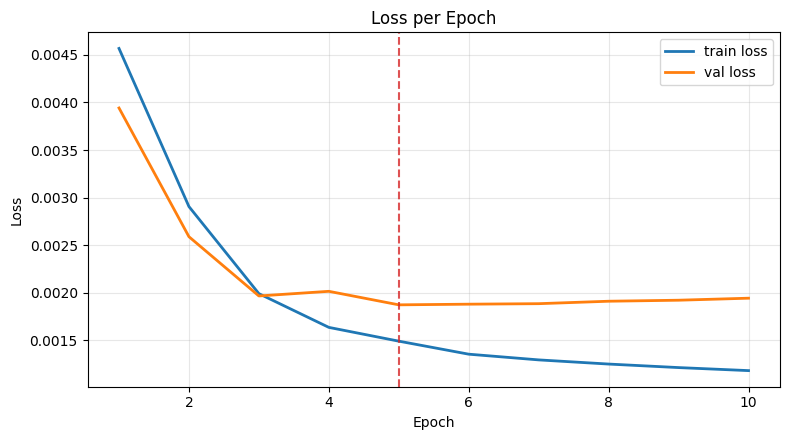

In [352]:
# Visualize training/validation loss by epoch
if len(train_history) == 0:
    print("No loss history available. Run the training cell first.")
else:
    epochs = np.arange(1, len(train_history) + 1)
    train_arr = np.array(train_history, dtype=float)
    val_arr = np.array(val_history, dtype=float)

    plt.figure(figsize=(8, 4.5))
    plt.plot(epochs, train_arr, label="train loss", linewidth=2.0)

    if np.isfinite(val_arr).any():
        plt.plot(epochs, val_arr, label="val loss", linewidth=2.0)
        best_epoch_plot = int(np.nanargmin(val_arr)) + 1
        best_loss_plot = float(np.nanmin(val_arr))
        plt.axvline(best_epoch_plot, color="tab:red", linestyle="--", alpha=0.8)
        print(f"Best epoch by validation loss: {best_epoch_plot} (loss={best_loss_plot:.6f})")
    else:
        best_epoch_plot = int(np.argmin(train_arr)) + 1
        best_loss_plot = float(np.min(train_arr))
        plt.axvline(best_epoch_plot, color="tab:red", linestyle="--", alpha=0.8)
        print(f"Validation not available. Best epoch by training loss: {best_epoch_plot} (loss={best_loss_plot:.6f})")

    plt.title("Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [353]:
# Test + save results
if test_idx.numel() > 0:
    test_loss = _run_epoch(
        x=x,
        target=target,
        idx=test_idx,
        model=model,
        optimizer=None,
        class_weights=class_weights,
        batch_size=BATCH_SIZE,
        device_obj=DEVICE,
        train=False,
    )
    print(f"test loss {test_loss:.6f}")
else:
    print("No test split selected. Skipping test loss.")

model.eval()
with torch.no_grad():
    logits, z = model(x.to(DEVICE))

recon_vis = torch.argmax(logits, dim=1, keepdim=True).float().cpu()
input_vis = target.unsqueeze(1).float()
z_vec = z.flatten(start_dim=1).detach().cpu()

if test_idx.numel() > 0:
    # Pick the most informative test slice (largest foreground ratio).
    test_fg_ratio = (target[test_idx] > 0).float().mean(dim=(1, 2))
    best_test_pos = int(torch.argmax(test_fg_ratio).item())
    preview_choice = int(test_idx[best_test_pos].item())
    print(
        f"Preview test slice: idx={preview_choice}, "
        f"foreground_ratio={float(test_fg_ratio[best_test_pos]):.4f}"
    )
elif val_idx.numel() > 0:
    val_fg_ratio = (target[val_idx] > 0).float().mean(dim=(1, 2))
    best_val_pos = int(torch.argmax(val_fg_ratio).item())
    preview_choice = int(val_idx[best_val_pos].item())
    print(
        f"Preview val slice: idx={preview_choice}, "
        f"foreground_ratio={float(val_fg_ratio[best_val_pos]):.4f}"
    )
else:
    train_fg_ratio = (target[train_idx] > 0).float().mean(dim=(1, 2))
    best_train_pos = int(torch.argmax(train_fg_ratio).item())
    preview_choice = int(train_idx[best_train_pos].item())
    print(
        f"Preview train slice: idx={preview_choice}, "
        f"foreground_ratio={float(train_fg_ratio[best_train_pos]):.4f}"
    )

source_path = Path(slice_source_paths[preview_choice])
nifti_stem = source_path.name
if nifti_stem.endswith(".nii.gz"):
    nifti_stem = nifti_stem[:-7]
else:
    nifti_stem = Path(nifti_stem).stem

session_name = source_path.parent.name
prefix = f"{session_name}_{nifti_stem}"

preview_path = OUTPUT_DIR / f"{prefix}_preview.png"
latent_path = OUTPUT_DIR / f"{prefix}_latent.npy"
pca_path = OUTPUT_DIR / f"{prefix}_pca.png"

np.save(latent_path, z_vec.numpy())
if MAKE_PCA:
    _save_pca_plot(z_vec, pca_path)

input_slice = input_vis[preview_choice, 0].numpy()
recon_slice = recon_vis[preview_choice, 0].numpy()
mismatch_ratio = float(np.mean(input_slice != recon_slice))
mean_abs_diff = float(np.mean(np.abs(input_slice - recon_slice)))
print(
    f"Preview difference (idx={preview_choice}): mismatch={mismatch_ratio * 100:.2f}% ",
    f"mean_abs_diff={mean_abs_diff:.4f}"
)
_save_preview(
    input_slice,
    recon_slice,
    preview_path,
    vmin=0,
    vmax=NUM_CLASSES - 1,
    preview_idx=preview_choice,
    mismatch_ratio=mismatch_ratio,
    mean_abs_diff=mean_abs_diff,
)

print("Saved preview:", preview_path)
print("Saved latent:", latent_path)
if MAKE_PCA:
    print("Saved PCA:", pca_path)

# Subject-level fixed normalized informative slice (one point per test subject)
fixed_norm_pos = float(np.clip(globals().get("FIXED_SLICE_NORM_POS", 0.5), 0.0, 1.0))
fixed_min_fg_ratio = float(globals().get("FIXED_SLICE_MIN_FG_RATIO", 0.01))

if len(test_subject_ids) == 0:
    print("No test subjects available for fixed-slice latent export.")
else:
    fixed_subject_ids: list[str] = []
    fixed_global_indices: list[int] = []
    fixed_fg_ratios: list[float] = []
    fixed_source_paths: list[str] = []
    fixed_latents: list[np.ndarray] = []

    test_idx_np = test_idx.detach().cpu().numpy().astype(int)
    for sid in test_subject_ids:
        sid_indices = sorted(int(i) for i in test_idx_np if slice_subject_ids[int(i)] == sid)
        if len(sid_indices) == 0:
            continue

        sid_fg = (target[sid_indices] > 0).float().mean(dim=(1, 2)).detach().cpu().numpy()
        informative_positions = np.where(sid_fg > fixed_min_fg_ratio)[0]
        if informative_positions.size == 0:
            informative_positions = np.arange(len(sid_indices))

        pick_rank = int(round((informative_positions.size - 1) * fixed_norm_pos))
        pick_rank = max(0, min(informative_positions.size - 1, pick_rank))
        local_pos = int(informative_positions[pick_rank])
        global_idx = int(sid_indices[local_pos])

        fixed_subject_ids.append(str(sid))
        fixed_global_indices.append(global_idx)
        fixed_fg_ratios.append(float(sid_fg[local_pos]))
        fixed_source_paths.append(str(slice_source_paths[global_idx]))
        fixed_latents.append(z_vec[global_idx].numpy())

    if len(fixed_latents) == 0:
        print("Fixed-slice export skipped: no eligible test slices found.")
    else:
        fixed_lat_arr = np.stack(fixed_latents, axis=0)

        fixed_latent_path = OUTPUT_DIR / f"test_subject_fixedslice_latent_seed{SPLIT_SEED}.npy"
        fixed_meta_path = OUTPUT_DIR / f"test_subject_fixedslice_meta_seed{SPLIT_SEED}.npz"
        fixed_pca_path = OUTPUT_DIR / f"test_subject_fixedslice_pca_seed{SPLIT_SEED}.png"

        np.save(fixed_latent_path, fixed_lat_arr)
        np.savez(
            fixed_meta_path,
            subject_id=np.array(fixed_subject_ids),
            global_slice_index=np.array(fixed_global_indices, dtype=np.int64),
            fg_ratio=np.array(fixed_fg_ratios, dtype=np.float32),
            source_path=np.array(fixed_source_paths),
            norm_pos=np.array([fixed_norm_pos], dtype=np.float32),
            min_fg_ratio=np.array([fixed_min_fg_ratio], dtype=np.float32),
        )

        if fixed_lat_arr.shape[0] >= 2:
            z_subj = fixed_lat_arr - fixed_lat_arr.mean(axis=0, keepdims=True)
            _, _, vt_subj = np.linalg.svd(z_subj, full_matrices=False)
            k_subj = min(2, vt_subj.shape[0])
            proj_subj = z_subj @ vt_subj[:k_subj].T
            if k_subj == 1:
                proj_subj = np.concatenate([proj_subj, np.zeros((proj_subj.shape[0], 1))], axis=1)
        else:
            proj_subj = np.zeros((fixed_lat_arr.shape[0], 2), dtype=np.float32)

        plt.figure(figsize=(5, 5))
        plt.scatter(proj_subj[:, 0], proj_subj[:, 1], s=36)
        for i, sid in enumerate(fixed_subject_ids):
            plt.annotate(sid, (proj_subj[i, 0], proj_subj[i, 1]), fontsize=8, alpha=0.8)
        plt.title("PCA of test subjects (fixed normalized informative slice)")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.tight_layout()
        plt.savefig(fixed_pca_path, dpi=150)
        plt.close()

        print("Saved fixed-slice test latent:", fixed_latent_path)
        print("Saved fixed-slice test metadata:", fixed_meta_path)
        print("Saved fixed-slice test PCA:", fixed_pca_path)
        print("Fixed-slice subjects:", fixed_subject_ids)

test loss 0.001772
Preview test slice: idx=514, foreground_ratio=0.2985
Preview difference (idx=514): mismatch=0.15%  mean_abs_diff=0.0023
Saved preview: outputs\OAS31167_ses-d0769_T1w_norm_seg_preview.png
Saved latent: outputs\OAS31167_ses-d0769_T1w_norm_seg_latent.npy
Saved PCA: outputs\OAS31167_ses-d0769_T1w_norm_seg_pca.png
Saved fixed-slice test latent: outputs\test_subject_fixedslice_latent_seed202.npy
Saved fixed-slice test metadata: outputs\test_subject_fixedslice_meta_seed202.npz
Saved fixed-slice test PCA: outputs\test_subject_fixedslice_pca_seed202.png
Fixed-slice subjects: ['OAS31165', 'OAS31166', 'OAS31167', 'OAS31168', 'OAS31169', 'OAS31170', 'OAS31171', 'OAS31172']


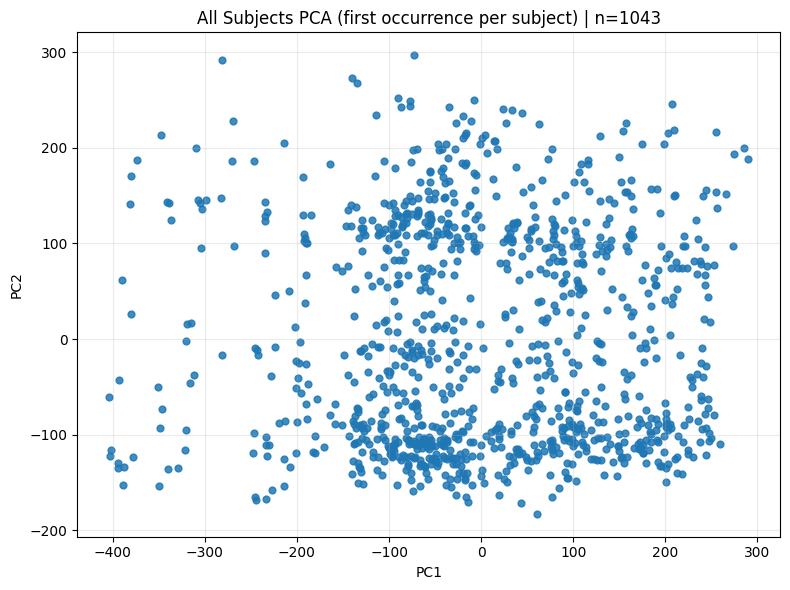

Chunk files detected: 70
Chunks loaded: 70
Rows before dedup: 1043
Unique subjects after dedup: 1043
Latent shape: (1043, 16384)
PCA explained ratio [PC1, PC2]: [0.25370433926582336, 0.1664832979440689]
Saved merged latent: outputs\all_subjects_latent_firstocc.npy
Saved merged PCA2D: outputs\all_subjects_pca2d_firstocc.npy
Saved merged meta: outputs\all_subjects_meta_firstocc.npz
Saved merged PCA plot: outputs\all_subjects_pca_firstocc.png


In [354]:
# Aggregate all chunk-level fixed-slice latents into one subject-level dataset + global PCA
chunk_latent_files = sorted(
    OUTPUT_DIR.glob("test_subject_fixedslice_latent_seed*.npy"),
    key=lambda p: int(p.stem.split("seed")[-1]),
)

if len(chunk_latent_files) == 0:
    raise FileNotFoundError("No chunk latent files found: outputs/test_subject_fixedslice_latent_seed*.npy")

first_subject_record: dict[str, dict[str, object]] = {}
total_rows = 0
loaded_chunks = 0
skipped_chunks: list[tuple[int, str]] = []

for latent_file in chunk_latent_files:
    seed = int(latent_file.stem.split("seed")[-1])
    meta_file = OUTPUT_DIR / f"test_subject_fixedslice_meta_seed{seed}.npz"
    if not meta_file.exists():
        skipped_chunks.append((seed, "missing meta"))
        continue

    lat_chunk = np.load(latent_file)
    with np.load(meta_file, allow_pickle=True) as meta:
        if "subject_id" not in meta:
            skipped_chunks.append((seed, "meta missing subject_id"))
            continue

        subject_ids = np.array(meta["subject_id"]).astype(str)
        fg_ratio = np.array(meta["fg_ratio"], dtype=np.float32) if "fg_ratio" in meta else np.full(subject_ids.shape, np.nan, dtype=np.float32)
        source_path = np.array(meta["source_path"]).astype(str) if "source_path" in meta else np.array([""] * len(subject_ids), dtype=object)
        global_slice_index = np.array(meta["global_slice_index"], dtype=np.int64) if "global_slice_index" in meta else np.full(subject_ids.shape, -1, dtype=np.int64)

    if lat_chunk.shape[0] != len(subject_ids):
        skipped_chunks.append((seed, f"row mismatch latent={lat_chunk.shape[0]} meta={len(subject_ids)}"))
        continue

    loaded_chunks += 1
    total_rows += int(lat_chunk.shape[0])

    for i, sid in enumerate(subject_ids):
        if sid in first_subject_record:
            continue  # Keep first occurrence by seed order.
        first_subject_record[sid] = {
            "latent": lat_chunk[i].astype(np.float32, copy=False),
            "seed": seed,
            "fg_ratio": float(fg_ratio[i]),
            "source_path": str(source_path[i]),
            "global_slice_index": int(global_slice_index[i]),
            "latent_file": str(latent_file.name),
        }

if len(first_subject_record) == 0:
    raise ValueError("No valid subject records found while aggregating chunk files.")

subject_ids_sorted = sorted(first_subject_record.keys())
all_latents = np.stack([first_subject_record[sid]["latent"] for sid in subject_ids_sorted], axis=0)
all_seed = np.array([first_subject_record[sid]["seed"] for sid in subject_ids_sorted], dtype=np.int64)
all_fg_ratio = np.array([first_subject_record[sid]["fg_ratio"] for sid in subject_ids_sorted], dtype=np.float32)
all_source_path = np.array([first_subject_record[sid]["source_path"] for sid in subject_ids_sorted])
all_global_slice_index = np.array([first_subject_record[sid]["global_slice_index"] for sid in subject_ids_sorted], dtype=np.int64)
all_latent_file = np.array([first_subject_record[sid]["latent_file"] for sid in subject_ids_sorted])

# PCA from merged latent vectors.
x_center = all_latents - all_latents.mean(axis=0, keepdims=True)
_, svals, vt = np.linalg.svd(x_center, full_matrices=False)
comp = min(2, vt.shape[0])
all_pca2d = x_center @ vt[:comp].T
if comp == 1:
    all_pca2d = np.concatenate([all_pca2d, np.zeros((all_pca2d.shape[0], 1), dtype=all_pca2d.dtype)], axis=1)

if all_latents.shape[0] > 1:
    var = (svals ** 2) / max(1, all_latents.shape[0] - 1)
    explained_ratio = (var / np.sum(var))[:2].astype(np.float32)
else:
    explained_ratio = np.array([1.0, 0.0], dtype=np.float32)

merged_latent_path = OUTPUT_DIR / "all_subjects_latent_firstocc.npy"
merged_pca2d_path = OUTPUT_DIR / "all_subjects_pca2d_firstocc.npy"
merged_meta_path = OUTPUT_DIR / "all_subjects_meta_firstocc.npz"
merged_pca_plot_path = OUTPUT_DIR / "all_subjects_pca_firstocc.png"

np.save(merged_latent_path, all_latents.astype(np.float32))
np.save(merged_pca2d_path, all_pca2d.astype(np.float32))
np.savez(
    merged_meta_path,
    subject_id=np.array(subject_ids_sorted),
    seed=all_seed,
    fg_ratio=all_fg_ratio,
    source_path=all_source_path,
    global_slice_index=all_global_slice_index,
    latent_file=all_latent_file,
    pca_explained_ratio=explained_ratio,
)

plt.figure(figsize=(8, 6))
plt.scatter(all_pca2d[:, 0], all_pca2d[:, 1], s=24, alpha=0.85)
plt.title(f"All Subjects PCA (first occurrence per subject) | n={all_pca2d.shape[0]}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(merged_pca_plot_path, dpi=160)
plt.show()
plt.close()

print("Chunk files detected:", len(chunk_latent_files))
print("Chunks loaded:", loaded_chunks)
print("Rows before dedup:", total_rows)
print("Unique subjects after dedup:", len(subject_ids_sorted))
print("Latent shape:", all_latents.shape)
print("PCA explained ratio [PC1, PC2]:", explained_ratio.tolist())
print("Saved merged latent:", merged_latent_path)
print("Saved merged PCA2D:", merged_pca2d_path)
print("Saved merged meta:", merged_meta_path)
print("Saved merged PCA plot:", merged_pca_plot_path)
if skipped_chunks:
    print("Skipped chunks (seed, reason):", skipped_chunks[:10])